# Meta-Confidence Model ( 4h )— All 15 Pairs

Exact replica of `notebooks_5/06_meta_confidence_model.ipynb` but trained on **all 15 pairs**.

Loads features from both `features_2/` (majors) and `features_3/` (crosses).

**Models saved to:** `backend/models_5.2/meta/`

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import warnings
import gc
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import mean_pinball_loss, roc_auc_score, precision_recall_curve

FEATURES_DIR_MAJORS = Path('../backend/data/features_2')
FEATURES_DIR_CROSSES = Path('../backend/data/features_3')
MODELS_DIR   = Path('../backend/models_5.2/3_quants')
META_DIR     = Path('../backend/models_5.2/meta')
META_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END = '2024-06-30'
AVG_SPREAD = 0.00028
MIN_Q50_THRESHOLD = AVG_SPREAD * 0.5  # only care about tradeable hours

print('Setup complete.')

Setup complete.


## 1. Load Data & Regenerate OOF Q50 Predictions

We need OOF (out-of-fold) predictions from the Q50 walk-forward CV on training data. These are predictions made by models that never saw those rows — no leakage.

In [2]:
# Load dataset from BOTH feature dirs (15 pairs total)
df_majors = pd.read_parquet(FEATURES_DIR_MAJORS / 'all_pairs_microstructure.parquet')
df_crosses = pd.read_parquet(FEATURES_DIR_CROSSES / 'all_pairs_microstructure.parquet')

print(f'Majors:  {df_majors.shape} — pairs: {df_majors["pair"].unique()}')
print(f'Crosses: {df_crosses.shape} — pairs: {df_crosses["pair"].unique()}')

df = pd.concat([df_majors, df_crosses]).sort_index()
del df_majors, df_crosses

label_cols   = [c for c in df.columns if c.startswith('label_')]
drop_cols    = label_cols + ['pair']
feature_cols = [c for c in df.columns if c not in drop_cols]
TARGET_COL = 'label_4H'

df_train = df[df.index <= TRAIN_END].copy()
df_test  = df[df.index > TRAIN_END].copy()

# Clean training data
y_all = df_train[TARGET_COL]
valid_mask = y_all.notna()
X_clean = df_train[feature_cols][valid_mask].ffill().fillna(0)
y_clean = y_all[valid_mask]
pairs_clean = df_train.loc[valid_mask, 'pair']

print(f'\nTrain: {len(X_clean):,} rows | Test: {len(df_test):,} rows')
print(f'Features: {len(feature_cols)}')
print(f'All pairs: {sorted(df["pair"].unique())}')

# Walk-forward splits (same as training notebook)
def walk_forward_splits(n, n_splits=5, test_ratio=0.1):
    test_size = int(n * test_ratio)
    splits = []
    for i in range(n_splits):
        test_start = int(n * 0.5) + i * (int(n * 0.5) // n_splits)
        test_end   = test_start + test_size
        if test_end > n:
            break
        splits.append((list(range(0, test_start)), list(range(test_start, test_end))))
    return splits

def get_lgbm_params(quantile):
    return {
        'objective': 'quantile', 'alpha': quantile, 'metric': 'quantile',
        'boosting_type': 'gbdt', 'n_estimators': 5000, 'learning_rate': 0.02,
        'num_leaves': 64, 'max_depth': 6, 'min_child_samples': 50,
        'feature_fraction': 0.7, 'bagging_fraction': 0.8, 'bagging_freq': 5,
        'reg_alpha': 0.1, 'reg_lambda': 0.1, 'random_state': 42,
        'n_jobs': -1, 'verbose': -1, 'device': 'gpu',
    }

Majors:  (702117, 67) — pairs: <ArrowStringArray>
['EURUSD', 'USDCHF', 'USDCAD', 'NZDUSD', 'GBPUSD', 'AUDUSD', 'USDJPY']
Length: 7, dtype: str
Crosses: (815903, 67) — pairs: <ArrowStringArray>
['EURJPY', 'EURGBP', 'EURAUD', 'AUDJPY', 'CADJPY', 'CHFJPY', 'AUDNZD',
 'GBPJPY']
Length: 8, dtype: str

Train: 1,335,228 rows | Test: 139,262 rows
Features: 64
All pairs: ['AUDJPY', 'AUDNZD', 'AUDUSD', 'CADJPY', 'CHFJPY', 'EURAUD', 'EURGBP', 'EURJPY', 'EURUSD', 'GBPJPY', 'GBPUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY']


In [3]:
# Regenerate OOF predictions for Q25, Q50, Q75
# These are predictions from walk-forward folds — each prediction is from a model
# that never saw that row during training. No leakage.

splits = walk_forward_splits(len(X_clean))
QUANTILES = [0.25, 0.50, 0.75]
QUANTILE_NAMES = ['Q25', 'Q50', 'Q75']

oof_preds = {q: np.full(len(X_clean), np.nan) for q in QUANTILES}

for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    print(f'Generating OOF for {q_name}...')
    params = get_lgbm_params(q)
    
    for fold, (train_idx, test_idx) in enumerate(splits):
        X_tr, y_tr = X_clean.iloc[train_idx], y_clean.iloc[train_idx]
        X_te, y_te = X_clean.iloc[test_idx], y_clean.iloc[test_idx]
        
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        
        oof_preds[q][test_idx] = model.predict(X_te)
    
    del model; gc.collect()
    valid_oof = ~np.isnan(oof_preds[q])
    print(f'  {q_name}: {valid_oof.sum():,} OOF predictions')

# Build OOF dataframe (only rows that have predictions from all quantiles)
has_oof = ~np.isnan(oof_preds[0.50])
print(f'\nTotal OOF rows: {has_oof.sum():,} / {len(X_clean):,}')

Generating OOF for Q25...
  Q25: 667,610 OOF predictions
Generating OOF for Q50...
  Q50: 667,610 OOF predictions
Generating OOF for Q75...
  Q75: 667,610 OOF predictions

Total OOF rows: 667,610 / 1,335,228


## 2. Build Meta-Features & Meta-Target

For each hour in the OOF set where |Q50| > 0.5x spread:
- **Meta-features:** 64 original features + Q50, Q25, Q75, |Q50|, IQR, confidence ratio, pair
- **Meta-target:** 1 if Q50 predicted correct direction, 0 if wrong

In [4]:
# Build meta-dataset from OOF predictions
oof_df = X_clean[has_oof].copy()
oof_df['Q25_oof'] = oof_preds[0.25][has_oof]
oof_df['Q50_oof'] = oof_preds[0.50][has_oof]
oof_df['Q75_oof'] = oof_preds[0.75][has_oof]
oof_df['abs_Q50'] = np.abs(oof_df['Q50_oof'])
oof_df['iqr'] = oof_df['Q75_oof'] - oof_df['Q25_oof']
oof_df['conf_ratio'] = oof_df['abs_Q50'] / oof_df['iqr'].clip(lower=1e-10)
oof_df['q50_dir'] = np.sign(oof_df['Q50_oof'])
oof_df['actual_return'] = y_clean.values[has_oof]
oof_df['actual_dir'] = np.sign(oof_df['actual_return'])
oof_df['pair'] = pairs_clean.values[has_oof]

# Meta-target: was Q50 correct on direction?
oof_df['q50_correct'] = (oof_df['q50_dir'] == oof_df['actual_dir']).astype(int)

# Filter to tradeable zone only (|Q50| > 0.5x spread)
tradeable = oof_df[oof_df['abs_Q50'] > MIN_Q50_THRESHOLD].copy()

print(f'OOF rows with predictions: {len(oof_df):,}')
print(f'Tradeable (|Q50| > 0.5x spread): {len(tradeable):,}')
print(f'Q50 accuracy in tradeable zone: {tradeable["q50_correct"].mean():.1%}')
print(f'Class balance: {tradeable["q50_correct"].value_counts().to_dict()}')

# Meta-features: original features + quantile model outputs
meta_feature_cols = feature_cols + ['Q50_oof', 'Q25_oof', 'Q75_oof', 'abs_Q50', 'iqr', 'conf_ratio']
print(f'Meta-features: {len(meta_feature_cols)} ({len(feature_cols)} original + 6 quantile-derived)')

OOF rows with predictions: 667,610
Tradeable (|Q50| > 0.5x spread): 104,472
Q50 accuracy in tradeable zone: 56.1%
Class balance: {1: 58570, 0: 45902}
Meta-features: 70 (64 original + 6 quantile-derived)


## 3. Train Meta-Model (Walk-Forward CV)

Binary classifier: predicts P(Q50 is correct) for each tradeable hour.
Walk-forward CV within training data to avoid leakage.

In [5]:
# Meta-model parameters — lighter than Q50 model to avoid overfitting on smaller dataset
meta_params = {
    'objective':         'binary',
    'metric':            'auc',
    'boosting_type':     'gbdt',
    'n_estimators':      3000,
    'learning_rate':     0.01,
    'num_leaves':        32,
    'max_depth':         4,
    'min_child_samples': 30,
    'feature_fraction':  0.6,
    'bagging_fraction':  0.7,
    'bagging_freq':      5,
    'reg_alpha':         0.5,
    'reg_lambda':        0.5,
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,
    'device':            'gpu',
    'is_unbalance':      True,
}

# Walk-forward CV on the tradeable subset
X_meta = tradeable[meta_feature_cols]
y_meta = tradeable['q50_correct']

meta_splits = walk_forward_splits(len(X_meta), n_splits=5, test_ratio=0.1)
meta_oof_proba = np.full(len(X_meta), np.nan)
meta_best_iters = []
meta_aucs = []

print(f'Meta-model training: {len(X_meta):,} tradeable rows')
print(f'Class balance: {y_meta.mean():.1%} correct\n')

for fold, (train_idx, test_idx) in enumerate(meta_splits):
    X_tr, y_tr = X_meta.iloc[train_idx], y_meta.iloc[train_idx]
    X_te, y_te = X_meta.iloc[test_idx], y_meta.iloc[test_idx]
    
    model = lgb.LGBMClassifier(**meta_params)
    model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    
    proba = model.predict_proba(X_te)[:, 1]
    meta_oof_proba[test_idx] = proba
    
    auc = roc_auc_score(y_te, proba)
    meta_aucs.append(auc)
    meta_best_iters.append(model.best_iteration_)
    
    print(f'  Fold {fold+1}: AUC={auc:.4f}, best_iter={model.best_iteration_}, '
          f'train_acc={y_tr.mean():.1%}, test_acc={y_te.mean():.1%}')

del model; gc.collect()

print(f'\nMean CV AUC: {np.mean(meta_aucs):.4f}')
print(f'Avg best iterations: {int(np.mean(meta_best_iters))}')

Meta-model training: 104,472 tradeable rows
Class balance: 56.1% correct

  Fold 1: AUC=0.5629, best_iter=14, train_acc=55.9%, test_acc=56.5%
  Fold 2: AUC=0.5640, best_iter=46, train_acc=56.0%, test_acc=55.4%
  Fold 3: AUC=0.5516, best_iter=11, train_acc=55.9%, test_acc=56.7%
  Fold 4: AUC=0.5521, best_iter=59, train_acc=56.0%, test_acc=56.4%
  Fold 5: AUC=0.5752, best_iter=18, train_acc=56.0%, test_acc=56.2%

Mean CV AUC: 0.5612
Avg best iterations: 29


## 4. OOF Meta-Model Evaluation

Sweep meta-model probability thresholds on OOF predictions. Can we find a sweet spot with 500+ trades and 85%+ accuracy?

In [6]:
# Evaluate meta-model OOF at different probability thresholds
has_meta_oof = ~np.isnan(meta_oof_proba)
oof_eval = tradeable[has_meta_oof].copy()
oof_eval['meta_proba'] = meta_oof_proba[has_meta_oof]

print(f'OOF rows with meta predictions: {len(oof_eval):,}')
print(f'\n{"Threshold":<12} {"Trades":>8} {"WR":>8} {"EV/trade":>12} {"TotalPnL":>10}')
print('-' * 55)

for thresh in np.arange(0.50, 0.96, 0.05):
    mask = oof_eval['meta_proba'] > thresh
    n = mask.sum()
    if n < 10:
        continue
    s = oof_eval[mask]
    pnl = s['q50_dir'] * s['actual_return'] - AVG_SPREAD
    wr = s['q50_correct'].mean()
    flag = ' <<<' if wr >= 0.80 and n >= 100 else ''
    print(f'P > {thresh:.2f}    {n:>8,} {wr:>7.1%} {pnl.mean():>12.6f} {pnl.sum():>10.4f}{flag}')

OOF rows with meta predictions: 52,235

Threshold      Trades       WR     EV/trade   TotalPnL
-------------------------------------------------------
P > 0.50      52,235   56.2%     0.000224    11.7124
P > 0.55      18,804   61.9%     0.000887    16.6709
P > 0.60       2,294   89.5%     0.006175    14.1658 <<<
P > 0.65         901   92.1%     0.006461     5.8210 <<<
P > 0.70         538   97.2%     0.008787     4.7275 <<<


## 5. Train Final Meta-Model & Test Set Evaluation

Train final meta-model on ALL training data tradeable rows. Then evaluate on genuinely unseen test set.

In [7]:
# Train final meta-model on all tradeable training rows
avg_iter = max(50, int(np.mean(meta_best_iters)))
final_meta = lgb.LGBMClassifier(**{**meta_params, 'n_estimators': avg_iter})
final_meta.fit(X_meta, y_meta)

print(f'Final meta-model trained: {avg_iter} iterations on {len(X_meta):,} rows')

# Save meta-model
joblib.dump({
    'model': final_meta,
    'meta_feature_cols': meta_feature_cols,
    'min_q50_threshold': MIN_Q50_THRESHOLD,
    'train_end': TRAIN_END,
    'cv_auc': np.mean(meta_aucs),
    'n_iters': avg_iter,
}, META_DIR / 'meta_confidence.joblib')

size_mb = (META_DIR / 'meta_confidence.joblib').stat().st_size / 1024 / 1024
print(f'Saved to {META_DIR / "meta_confidence.joblib"} ({size_mb:.1f} MB)')

Final meta-model trained: 50 iterations on 104,472 rows
Saved to ..\backend\models_5.2\meta\meta_confidence.joblib (0.1 MB)


In [8]:
# --- Test Set Evaluation ---
# Step 1: Load Q50 model and predict on test set
X_test = df_test[feature_cols].ffill().fillna(0)
y_test = df_test[TARGET_COL]
valid_test = y_test.notna()
X_test_clean = X_test[valid_test]
y_test_clean = y_test[valid_test]

# Get Q25/Q50/Q75 predictions on test set
q_preds_test = {}
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    q_int = int(q * 100)
    bundle = joblib.load(MODELS_DIR / f'model_1H_Q{q_int}.joblib')
    q_preds_test[q_name] = bundle['model'].predict(X_test_clean)

# Build test results with meta-features
test_results = X_test_clean.copy()
test_results['Q25_oof'] = q_preds_test['Q25']  # named _oof to match meta_feature_cols
test_results['Q50_oof'] = q_preds_test['Q50']
test_results['Q75_oof'] = q_preds_test['Q75']
test_results['abs_Q50'] = np.abs(test_results['Q50_oof'])
test_results['iqr'] = test_results['Q75_oof'] - test_results['Q25_oof']
test_results['conf_ratio'] = test_results['abs_Q50'] / test_results['iqr'].clip(lower=1e-10)
test_results['pred_dir'] = np.sign(test_results['Q50_oof'])
test_results['actual_return'] = y_test_clean.values
test_results['actual_dir'] = np.sign(test_results['actual_return'])
test_results['pair'] = df_test.loc[valid_test, 'pair'].values

# Step 2: Filter to tradeable zone
test_tradeable = test_results[test_results['abs_Q50'] > MIN_Q50_THRESHOLD].copy()
print(f'Test set tradeable (|Q50| > 0.5x spread): {len(test_tradeable):,} rows')

# Step 3: Apply meta-model
meta_proba_test = final_meta.predict_proba(test_tradeable[meta_feature_cols])[:, 1]
test_tradeable['meta_proba'] = meta_proba_test

print(f'Meta-model probability distribution on test:')
print(f'  mean={meta_proba_test.mean():.3f}, median={np.median(meta_proba_test):.3f}')
print(f'  min={meta_proba_test.min():.3f}, max={meta_proba_test.max():.3f}')

Test set tradeable (|Q50| > 0.5x spread): 21,922 rows
Meta-model probability distribution on test:
  mean=0.538, median=0.527
  min=0.516, max=0.721


In [9]:
# Sweep meta-model thresholds on TEST set
n_test_days = (test_tradeable.index.max() - test_tradeable.index.min()).days

print(f'META-MODEL TEST SET RESULTS (unseen, post {TRAIN_END})')
print(f'\n{"Threshold":<12} {"Trades":>8} {"Tr/day":>8} {"WR":>8} {"EV/trade":>12} {"TotalPnL":>10} {"Sharpe":>8}')
print('-' * 75)

test_sweep = []
for thresh in np.arange(0.50, 0.96, 0.05):
    mask = test_tradeable['meta_proba'] > thresh
    n = mask.sum()
    if n < 10:
        continue
    s = test_tradeable[mask]
    pnl = s['pred_dir'] * s['actual_return'] - AVG_SPREAD
    wr = (s['pred_dir'] == s['actual_dir']).mean()
    ev = pnl.mean()
    total_pnl = pnl.sum()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    daily = n / n_test_days
    
    test_sweep.append({'thresh': thresh, 'trades': n, 'daily': daily, 'wr': wr, 'ev': ev, 'pnl': total_pnl, 'sharpe': sharpe})
    flag = ' <<<' if wr >= 0.80 and n >= 100 else (' <<' if wr >= 0.70 and n >= 200 else '')
    print(f'P > {thresh:.2f}    {n:>8,} {daily:>8.2f} {wr:>7.1%} {ev:>12.6f} {total_pnl:>10.4f} {sharpe:>8.2f}{flag}')

# Compare with Q50-only baselines
print(f'\n--- Q50-only baselines (no meta-model) ---')
for name, thresh in [('|Q50|>0.5x', AVG_SPREAD*0.5), ('|Q50|>1x', AVG_SPREAD), ('|Q50|>2x', AVG_SPREAD*2)]:
    mask = test_results['abs_Q50'] > thresh
    n = mask.sum()
    if n < 10: continue
    s = test_results[mask]
    pnl = s['pred_dir'] * s['actual_return'] - AVG_SPREAD
    wr = (s['pred_dir'] == s['actual_dir']).mean()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    print(f'{name:<12} {n:>8,} {n/n_test_days:>8.2f} {wr:>7.1%} {pnl.mean():>12.6f} {pnl.sum():>10.4f} {sharpe:>8.2f}')

META-MODEL TEST SET RESULTS (unseen, post 2024-06-30)

Threshold      Trades   Tr/day       WR     EV/trade   TotalPnL   Sharpe
---------------------------------------------------------------------------
P > 0.50      21,922    40.00   55.0%     0.000142     3.1054     1.92
P > 0.55       2,804     5.12   70.2%     0.002262     6.3426    14.59 <<
P > 0.60         902     1.65   86.0%     0.006818     6.1497    26.18 <<<
P > 0.65         431     0.79   93.5%     0.012744     5.4928    37.62 <<<
P > 0.70         283     0.52   98.2%     0.017457     4.9404    46.71 <<<

--- Q50-only baselines (no meta-model) ---
|Q50|>0.5x     21,922    40.00   55.0%     0.000142     3.1054     1.92
|Q50|>1x        5,427     9.90   61.6%     0.001107     6.0082     9.19
|Q50|>2x        1,476     2.69   73.6%     0.004186     6.1788    19.72


## 6. Equity Curves — Meta-Model vs Q50-Only

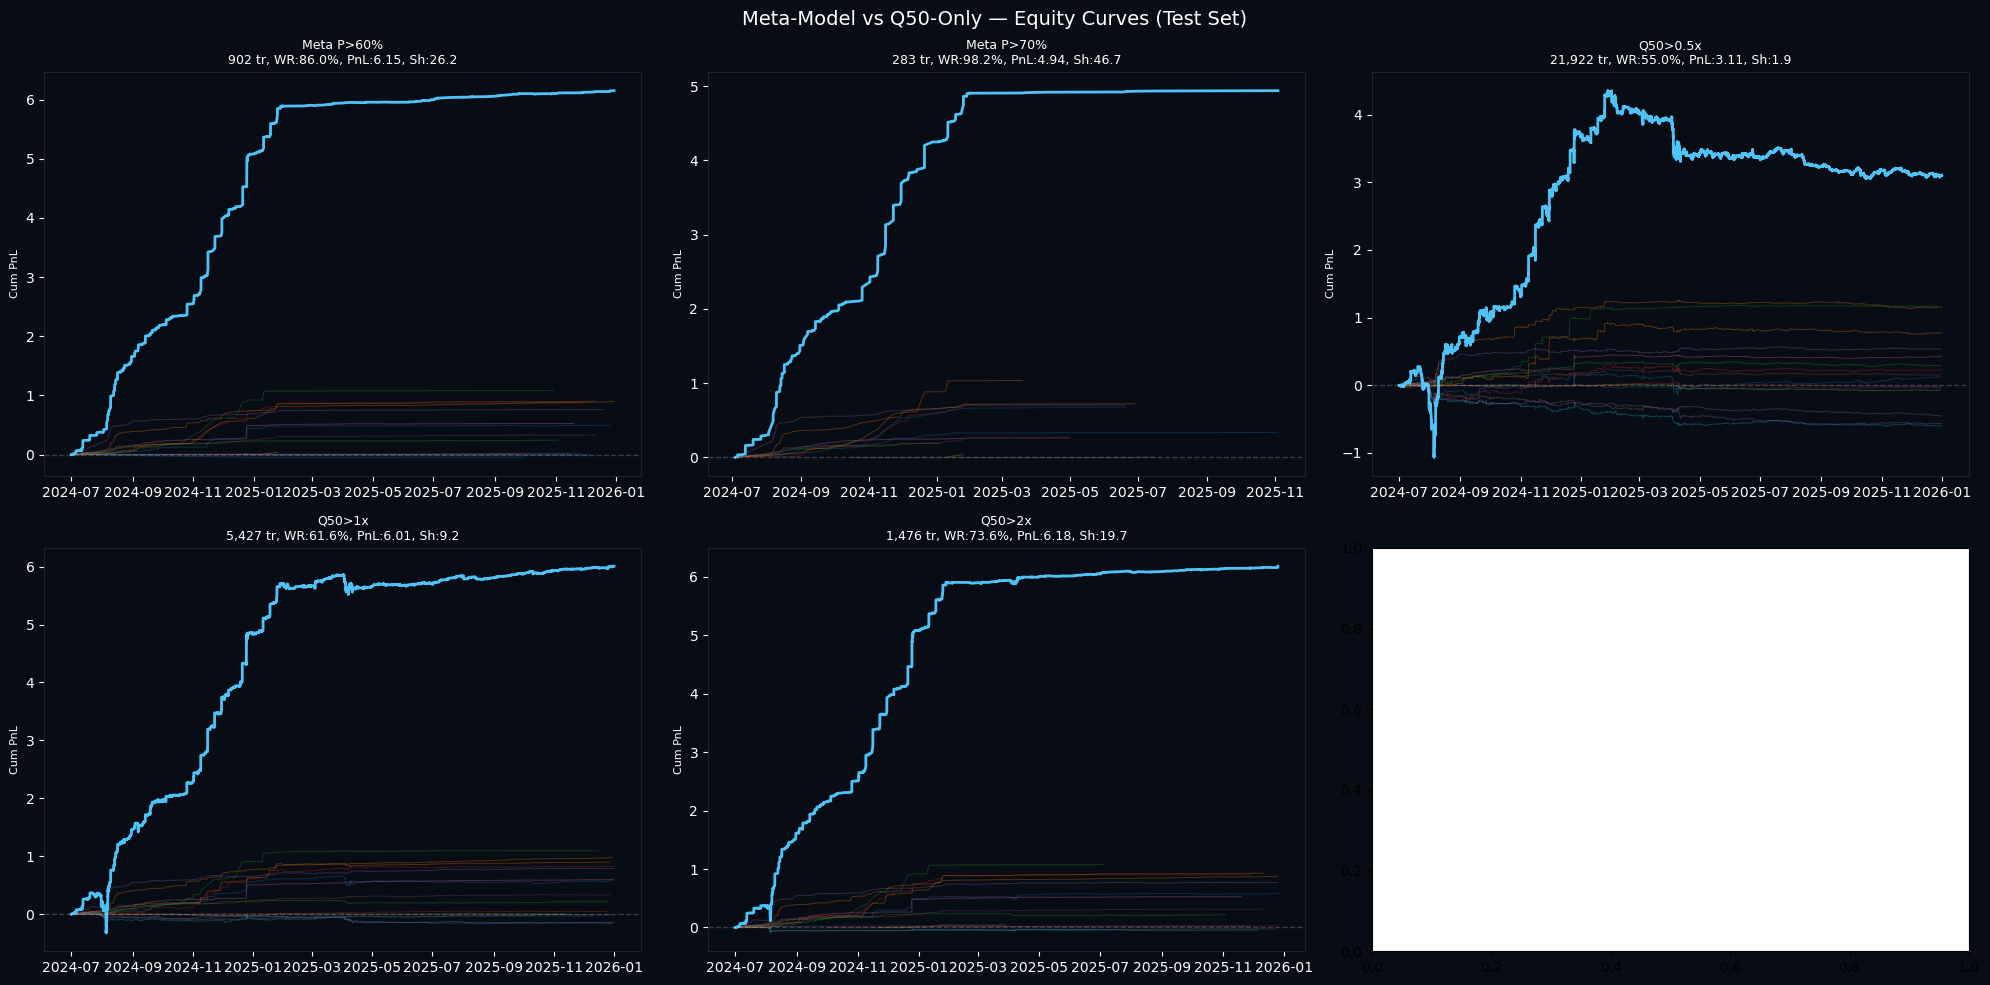

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.patch.set_facecolor('#080c14')

# Define strategies to compare
strategies = {}

# Meta-model at different thresholds
for thresh in [0.60, 0.70, 0.80]:
    mask = test_tradeable['meta_proba'] > thresh
    if mask.sum() >= 10:
        s = test_tradeable[mask]
        strategies[f'Meta P>{thresh:.0%}'] = (s.index, s['pred_dir'], s['actual_return'], s['actual_dir'], s.get('pair', None))

# Q50-only baselines
for name, thresh in [('Q50>0.5x', AVG_SPREAD*0.5), ('Q50>1x', AVG_SPREAD), ('Q50>2x', AVG_SPREAD*2)]:
    mask = test_results['abs_Q50'] > thresh
    if mask.sum() >= 10:
        s = test_results[mask]
        strategies[name] = (s.index, s['pred_dir'], s['actual_return'], s['actual_dir'], s['pair'])

for ax, (name, (idx, pred_dir, actual_ret, actual_dir, pair_col)) in zip(axes.flatten(), strategies.items()):
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
    
    pnl = pred_dir * actual_ret - AVG_SPREAD
    cum_pnl = pnl.cumsum()
    
    # Per-pair if available
    if pair_col is not None:
        for p in sorted(pair_col.unique()):
            pmask = pair_col == p
            pair_pnl = (pred_dir[pmask] * actual_ret[pmask] - AVG_SPREAD).cumsum()
            ax.plot(idx[pmask], pair_pnl.values, alpha=0.3, linewidth=0.7)
    
    ax.plot(idx, cum_pnl.values, color='#4fc3f7', linewidth=2)
    ax.axhline(0, color=(1,1,1,0.2), linewidth=1, linestyle='--')
    
    wr = (pred_dir == actual_dir).mean()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    ax.set_title(f'{name}\n{len(idx):,} tr, WR:{wr:.1%}, PnL:{pnl.sum():.2f}, Sh:{sharpe:.1f}', color='white', fontsize=9)
    ax.set_ylabel('Cum PnL', color='white', fontsize=8)

plt.suptitle('Meta-Model vs Q50-Only — Equity Curves (Test Set)', color='white', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Meta-Model Feature Importance

What does the meta-model use to decide "trust Q50" vs "don't trust Q50"?

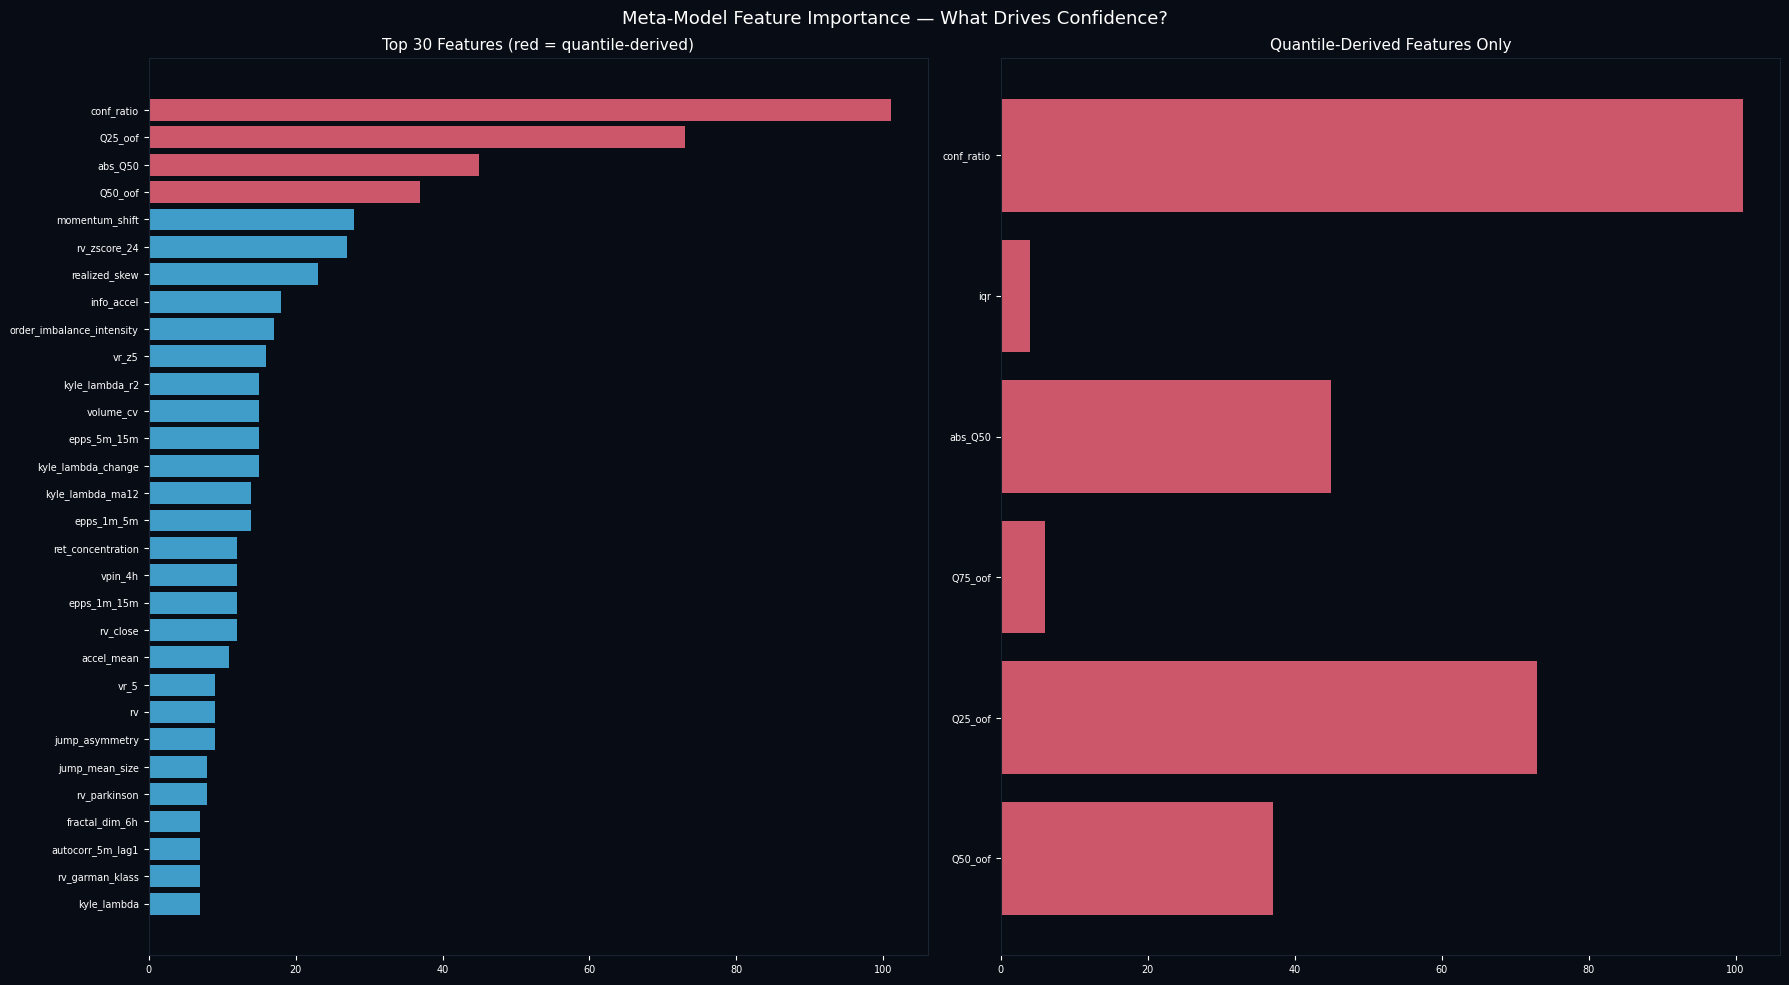


Top 10 meta-model features:
  1. conf_ratio: 101 (quantile-derived)
  2. Q25_oof: 73 (quantile-derived)
  3. abs_Q50: 45 (quantile-derived)
  4. Q50_oof: 37 (quantile-derived)
  5. momentum_shift: 28
  6. rv_zscore_24: 27
  7. realized_skew: 23
  8. info_accel: 18
  9. order_imbalance_intensity: 17
  10. vr_z5: 16


In [11]:
importance = pd.Series(final_meta.feature_importances_, index=meta_feature_cols)
importance = importance.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.patch.set_facecolor('#080c14')

# Top 30 features
for ax in axes:
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=7)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

top30 = importance.tail(30)
colors = ['#ff6b81' if f in ['Q50_oof', 'Q25_oof', 'Q75_oof', 'abs_Q50', 'iqr', 'conf_ratio'] else '#4fc3f7' for f in top30.index]
axes[0].barh(top30.index, top30.values, color=colors, alpha=0.8)
axes[0].set_title('Top 30 Features (red = quantile-derived)', color='white', fontsize=11)

# Quantile-derived features specifically
q_feats = importance[['Q50_oof', 'Q25_oof', 'Q75_oof', 'abs_Q50', 'iqr', 'conf_ratio']]
axes[1].barh(q_feats.index, q_feats.values, color='#ff6b81', alpha=0.8)
axes[1].set_title('Quantile-Derived Features Only', color='white', fontsize=11)

plt.suptitle('Meta-Model Feature Importance — What Drives Confidence?', color='white', fontsize=13)
plt.tight_layout()
plt.show()

# Print top 10
print('\nTop 10 meta-model features:')
for i, (feat, imp) in enumerate(importance.tail(10).iloc[::-1].items(), 1):
    tag = ' (quantile-derived)' if feat in ['Q50_oof', 'Q25_oof', 'Q75_oof', 'abs_Q50', 'iqr', 'conf_ratio'] else ''
    print(f'  {i}. {feat}: {imp}{tag}')

## 8. Per-Pair Breakdown — Meta-Model on Test Set

In [12]:
# Pick best meta threshold from test sweep (best total PnL with WR > 70%)
best_meta = max([r for r in test_sweep if r['wr'] >= 0.70], key=lambda x: x['pnl'], default=None)
if best_meta is None:
    best_meta = max(test_sweep, key=lambda x: x['pnl'])

META_THRESH = best_meta['thresh']
print(f'Selected meta threshold: P > {META_THRESH:.2f}')
print(f'  Trades: {best_meta["trades"]}, WR: {best_meta["wr"]:.1%}, PnL: {best_meta["pnl"]:.4f}\n')

# Per-pair breakdown at selected threshold
filtered = test_tradeable[test_tradeable['meta_proba'] > META_THRESH]

print(f'{"Pair":<10} {"Trades":>8} {"Tr/day":>8} {"WR":>8} {"EV/trade":>12} {"TotalPnL":>10}')
print('-' * 60)

for pair in sorted(filtered['pair'].unique()):
    p = filtered[filtered['pair'] == pair]
    pnl = p['pred_dir'] * p['actual_return'] - AVG_SPREAD
    wr = (p['pred_dir'] == p['actual_dir']).mean()
    flag = ' <<<' if pnl.mean() > 0 else ''
    print(f'{pair:<10} {len(p):>8,} {len(p)/n_test_days:>8.2f} {wr:>7.1%} {pnl.mean():>12.6f} {pnl.sum():>10.4f}{flag}')

Selected meta threshold: P > 0.55
  Trades: 2804, WR: 70.2%, PnL: 6.3426

Pair         Trades   Tr/day       WR     EV/trade   TotalPnL
------------------------------------------------------------
AUDJPY          260     0.47   66.5%     0.002008     0.5221 <<<
AUDNZD          586     1.07   76.6%     0.001658     0.9715 <<<
AUDUSD          119     0.22   75.6%     0.002101     0.2500 <<<
CADJPY          234     0.43   69.2%     0.003787     0.8860 <<<
CHFJPY          356     0.65   68.3%     0.002291     0.8155 <<<
EURAUD          163     0.30   69.3%     0.001902     0.3100 <<<
EURGBP          299     0.55   84.3%     0.001932     0.5775 <<<
EURJPY          120     0.22   60.0%     0.000217     0.0261 <<<
EURUSD           59     0.11   44.1%     0.000004     0.0002 <<<
GBPJPY           99     0.18   53.5%     0.000005     0.0005 <<<
GBPUSD           53     0.10   50.9%    -0.000824    -0.0436
NZDUSD          158     0.29   68.4%     0.005820     0.9195 <<<
USDCAD          139     0.2

## 9. Summary

In [13]:
print('=' * 80)
print('META-CONFIDENCE MODEL — SUMMARY')
print('=' * 80)

print(f'\nMeta-model: LightGBM binary classifier')
print(f'  CV AUC: {np.mean(meta_aucs):.4f}')
print(f'  Features: {len(meta_feature_cols)} (64 microstructure + 6 quantile-derived)')
print(f'  Trained on: tradeable hours (|Q50| > 0.5x spread) before {TRAIN_END}')
print(f'  Saved to: {META_DIR / "meta_confidence.joblib"}')

print(f'\n--- Best Strategy Comparison (Test Set) ---')
print(f'{"Strategy":<25} {"Trades":>8} {"Tr/day":>8} {"WR":>8} {"EV":>12} {"PnL":>10} {"Sharpe":>8}')
print('-' * 80)

# Q50-only baselines
for name, thresh in [('Q50>0.5x', AVG_SPREAD*0.5), ('Q50>1x', AVG_SPREAD), ('Q50>2x', AVG_SPREAD*2)]:
    mask = test_results['abs_Q50'] > thresh
    n = mask.sum()
    if n < 10: continue
    s = test_results[mask]
    pnl = s['pred_dir'] * s['actual_return'] - AVG_SPREAD
    wr = (s['pred_dir'] == s['actual_dir']).mean()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    print(f'{name:<25} {n:>8,} {n/n_test_days:>8.2f} {wr:>7.1%} {pnl.mean():>12.6f} {pnl.sum():>10.4f} {sharpe:>8.2f}')

# Meta-model
for r in test_sweep:
    if r['thresh'] in [0.60, 0.70, 0.80, META_THRESH]:
        name = f'Meta P>{r["thresh"]:.0%}'
        if r['thresh'] == META_THRESH:
            name += ' (BEST)'
        print(f'{name:<25} {r["trades"]:>8,} {r["daily"]:>8.2f} {r["wr"]:>7.1%} {r["ev"]:>12.6f} {r["pnl"]:>10.4f} {r["sharpe"]:>8.2f}')

print(f'\nGoal was: 500+ trades at 85%+ WR')
target_met = [r for r in test_sweep if r['trades'] >= 500 and r['wr'] >= 0.85]
if target_met:
    print(f'TARGET MET: {target_met[0]["trades"]} trades at {target_met[0]["wr"]:.1%} WR!')
else:
    closest = min(test_sweep, key=lambda r: abs(r['trades'] - 500) + abs(r['wr'] - 0.85) * 1000)
    print(f'Closest to target: {closest["trades"]} trades at {closest["wr"]:.1%} WR (P>{closest["thresh"]:.2f})')

META-CONFIDENCE MODEL — SUMMARY

Meta-model: LightGBM binary classifier
  CV AUC: 0.5612
  Features: 70 (64 microstructure + 6 quantile-derived)
  Trained on: tradeable hours (|Q50| > 0.5x spread) before 2024-06-30
  Saved to: ..\backend\models_5.2\meta\meta_confidence.joblib

--- Best Strategy Comparison (Test Set) ---
Strategy                    Trades   Tr/day       WR           EV        PnL   Sharpe
--------------------------------------------------------------------------------
Q50>0.5x                    21,922    40.00   55.0%     0.000142     3.1054     1.92
Q50>1x                       5,427     9.90   61.6%     0.001107     6.0082     9.19
Q50>2x                       1,476     2.69   73.6%     0.004186     6.1788    19.72
Meta P>55% (BEST)            2,804     5.12   70.2%     0.002262     6.3426    14.59

Goal was: 500+ trades at 85%+ WR
TARGET MET: 902 trades at 86.0% WR!
